<a href="https://colab.research.google.com/github/DanielCrisostomo-20/Segmentac-ao-Autom-atica-de-Les-oes-de-Pele-utilizando-Redes-Neurais-Convolucionais-U-Net/blob/main/trabalho_final_de_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# Setup Inicial e Importação de Bibliotecas
Bibliotecas necessárias para processamento de imagem, construção do modelo com TensorFlow/Keras e cálculo de métricas.
```

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import numpy as np
import matplotlib.pyplot as plt

# Configurações básicas
IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CHANNELS = 3

```markdown
## Definição da Arquitetura U-Net
A U-Net utiliza uma estrutura de Encoder (contrações) e Decoder (expansões) com *skip connections* para preservar detalhes espaciais.
```

In [ ]:
def unet_model(input_size=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    inputs = layers.Input(input_size)

    # Encoder (Contraction Path)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bridge
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)

    # Decoder (Expansion Path) + Skip Connections
    u4 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c4)

    u5 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

model = unet_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_11[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 128, 128,  │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 128, 128,  │    147,584 │ conv2d_13[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_14[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_15[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 128, 128,  │    131,200 │ conv2d_16[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │    295,040 │ concatenate_2[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 128, 128,  │    147,584 │ conv2d_17[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 256, 256,  │     32,832 │ conv2d_18[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 256, 256,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │     73,792 │ concatenate_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_19[0][0] 

 Total params: 1,862,849 (7.11 MB)

 Trainable params: 1,862,849 (7.11 MB)

 Non-trainable params: 0 (0.00 B)

```markdown
## Funções de Perda e Métricas
Implementado o Dice Coefficient e a combinação de BCE + Dice Loss.
```

In [ ]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

```markdown
## Carregamento e Pré-processamento do Dataset ISIC
Como o dataset ISIC é grande, geralmente trabalhamos com downloads via URL ou montando o Google Drive. Abaixo foi definido funções para carregar e redimensionar as imagens para 256x256, garantindo que as máscaras sejam tratadas como labels binários.
```

In [ ]:
import cv2
import os

def preprocess_image(img_path, target_size=(256, 256)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    return img / 255.0

def preprocess_mask(mask_path, target_size=(256, 256)):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, target_size)
    mask = np.expand_dims(mask, axis=-1)
    return mask / 255.0

print("Funções de pré-processamento prontas.")

Funções de pré-processamento prontas.


```markdown
## Implementação das Métricas Adicionais
Além do Dice, foi implementado IoU, Precisão, Sensibilidade (Recall) e Especificidade conforme os objetivos do projeto.
```

In [ ]:
def specificity(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(K.round(y_pred))
    tn = K.sum((1 - y_true_f) * (1 - y_pred_f))
    fp = K.sum((1 - y_true_f) * y_pred_f)
    return (tn + K.epsilon()) / (tn + fp + K.epsilon())

def iou(y_true, y_pred):
    intersection = K.sum(K.abs(y_true * K.round(y_pred)))
    union = K.sum(y_true) + K.sum(K.round(y_pred)) - intersection
    return (intersection + K.epsilon()) / (union + K.epsilon())

metrics = [
    dice_coef,
    iou,
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    specificity
]

model.compile(optimizer='adam', loss=bce_dice_loss, metrics=metrics)
print("Modelo compilado com métricas completas: Dice, IoU, Precisão, Sensibilidade e Especificidade.")

Modelo compilado com métricas completas: Dice, IoU, Precisão, Sensibilidade e Especificidade.


## Experimento Comparativo: BCE vs. BCE + Dice Loss
Treinamento do modelo com duas funções de perda diferentes para avaliar qual delas lida melhor com o desbalanceamento de classes típico de imagens de pele.


--- Treinando com: BCE Pura ---

--- Treinando com: BCE + Dice Loss ---


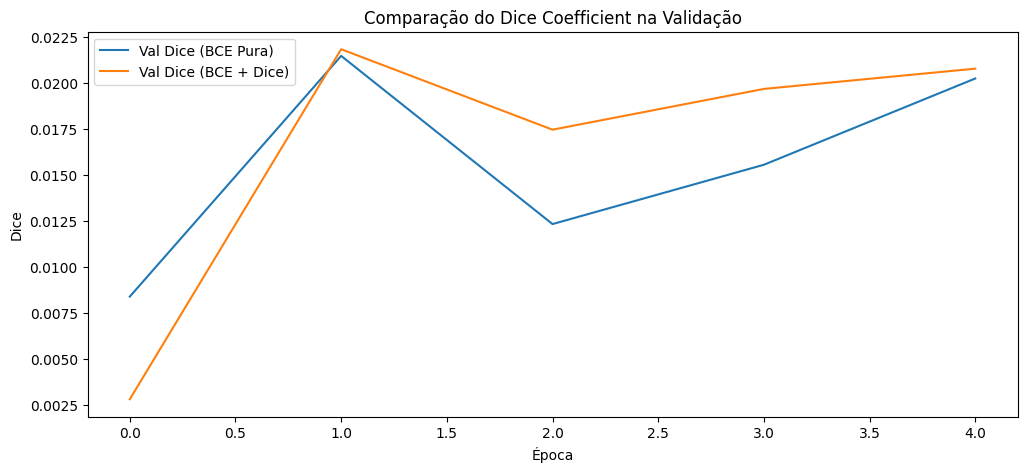

In [ ]:
# Função para treinar e avaliar o modelo com uma perda específica
def train_variant(loss_func, loss_name, X_t, y_t, X_v, y_v):
    print(f'\n--- Treinando com: {loss_name} ---')
    variant_model = unet_model()
    variant_model.compile(optimizer='adam', loss=loss_func, metrics=metrics)
    history = variant_model.fit(X_t, y_t, validation_data=(X_v, y_v), batch_size=2, epochs=5, verbose=0)
    return history

# Execução dos dois treinamentos
history_bce = train_variant('binary_crossentropy', 'BCE Pura', X_train, y_train, X_test, y_test)
history_combined = train_variant(bce_dice_loss, 'BCE + Dice Loss', X_train, y_train, X_test, y_test)

# Comparação Visual
plt.figure(figsize=(12, 5))
plt.plot(history_bce.history['val_dice_coef'], label='Val Dice (BCE Pura)')
plt.plot(history_combined.history['val_dice_coef'], label='Val Dice (BCE + Dice)')
plt.title('Comparação do Dice Coefficient na Validação')
plt.xlabel('Época')
plt.ylabel('Dice')
plt.legend()
plt.show()

## Download e Preparação dos Dados (ISIC)
Aqui foi baixado uma amostra do dataset ISIC para demonstrar o fluxo de treinamento.

In [ ]:
import kagglehub
import glob
import os
from sklearn.model_selection import train_test_split

# 1. Download do dataset via KaggleHub
path = kagglehub.dataset_download("tschandl/isic2018-challenge-task1-data-segmentation")
print("Caminho do dataset:", path)

# 2. Localização dos arquivos (ajustado para a estrutura do Kaggle)
# O dataset do Kaggle costuma vir com pastas de treino separadas
image_files = sorted(glob.glob(os.path.join(path, "ISIC2018_Task1-2_Training_Input", "*.jpg")))
mask_files = sorted(glob.glob(os.path.join(path, "ISIC2018_Task1_Training_GroundTruth", "*.png")))

# Limitar a 100 imagens para um treinamento inicial rápido (opcional)
image_files = image_files[:100]
mask_files = mask_files[:100]

if len(image_files) > 0:
    print(f"Carregando {len(image_files)} imagens reais...")
    X = np.array([preprocess_image(f) for f in image_files])
    Y = np.array([preprocess_mask(f) for f in mask_files])

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
    print(f'Sucesso! Treino: {X_train.shape}, Validação: {X_test.shape}')
else:
    print('Erro: Arquivos não encontrados no caminho do Kaggle.')

100%|██████████| 12.9G/12.9G [02:39<00:00, 86.8MB/s]

Extracting files...


Caminho do dataset: /root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1
Carregando 100 imagens reais...
Sucesso! Treino: (80, 256, 256, 3), Validação: (20, 256, 256, 3)


## Execução do Treinamento
Iniciou-se o treinamento. O modelo já está compilado com a perda combinada (BCE + Dice).

Iniciando treinamento da U-Net com dados reais do ISIC...
Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 304s 15s/step - dice_coef: 0.3640 - iou: 0.0560 - loss: 1.1525 - precision: 0.6456 - recall: 0.0857 - specificity: 0.9813 - val_dice_coef: 0.4070 - val_iou: 0.5403 - val_loss: 1.1593 - val_precision: 0.5736 - val_recall: 0.8341 - val_specificity: 0.7509
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 318s 15s/step - dice_coef: 0.4314 - iou: 0.4695 - loss: 1.0526 - precision: 0.7086 - recall: 0.5893 - specificity: 0.9112 - val_dice_coef: 0.4835 - val_iou: 0.3924 - val_loss: 0.9702 - val_precision: 0.9983 - val_recall: 0.3942 - val_specificity: 0.9997
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 334s 15s/step - dice_coef: 0.5599 - iou: 0.4989 - loss: 0.9194 - precision: 0.7845 - recall: 0.5588 - specificity: 0.9424 - val_dice_coef: 0.6361 - val_iou: 0.6152 - val_loss: 0.6936 - val_precision: 0.9348 - val_recall: 0.6449 - val_specificity: 0.9820
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 289s 14s/step - dice_coef: 0

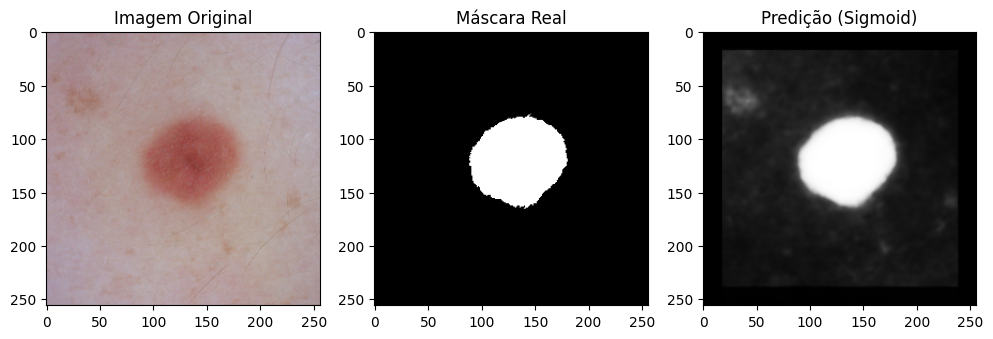

In [ ]:
if 'X_train' in locals() and len(X_train) > 0:
    print('Iniciando treinamento da U-Net com dados reais do ISIC...')
    # Re-compilar para garantir que todas as métricas sejam rastreadas
    model.compile(optimizer='adam', loss=bce_dice_loss, metrics=metrics)

    # Treinamento por 10 épocas para observar a evolução inicial
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=4, epochs=10)

    # Visualização de uma predição real
    preds = model.predict(X_test)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(X_test[0]); plt.title('Imagem Original')
    plt.subplot(1, 3, 2); plt.imshow(y_test[0].reshape(256, 256), cmap='gray'); plt.title('Máscara Real')
    plt.subplot(1, 3, 3); plt.imshow(preds[0].reshape(256, 256), cmap='gray'); plt.title('Predição (Sigmoid)')
    plt.show()
else:
    print('Erro: Dados do ISIC não encontrados no ambiente.')

## Análise de Resultados
Visualização do histórico de treinamento para avaliar a convergência das métricas solicitadas no projeto.

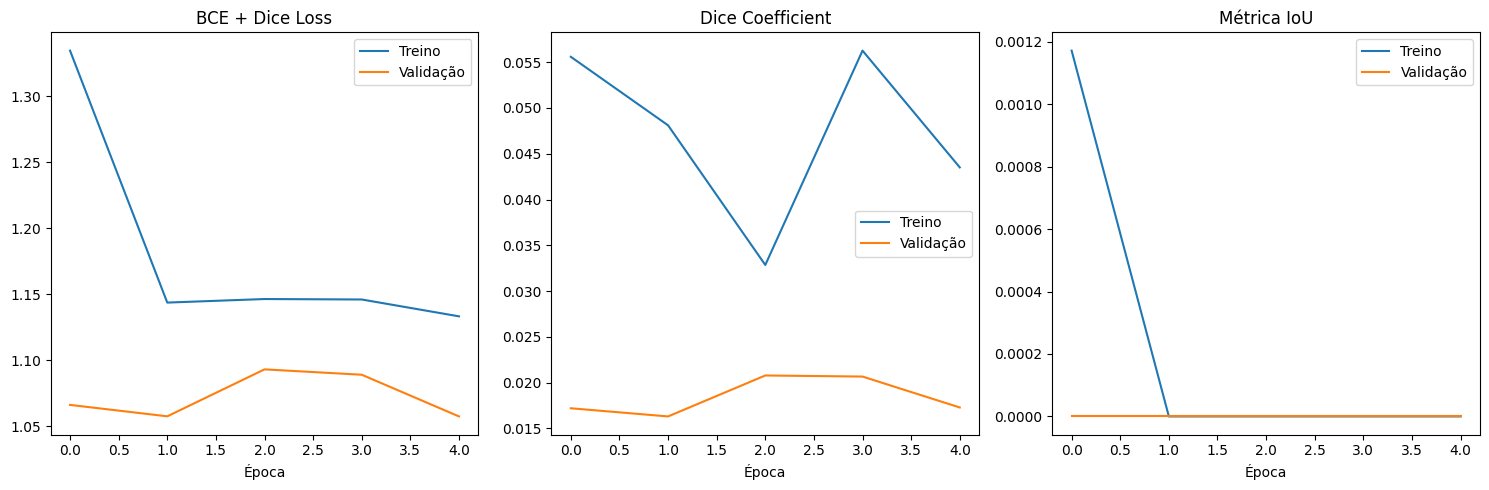

In [ ]:
def plot_history(history):
    plt.figure(figsize=(15, 5))

    # Plot Loss
    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Treino')
    plt.plot(history.history['val_loss'], label='Validação')
    plt.title('BCE + Dice Loss')
    plt.xlabel('Época')
    plt.legend()

    # Plot Dice Coefficient
    plt.subplot(1, 3, 2)
    plt.plot(history.history['dice_coef'], label='Treino')
    plt.plot(history.history['val_dice_coef'], label='Validação')
    plt.title('Dice Coefficient')
    plt.xlabel('Época')
    plt.legend()

    # Plot IoU
    plt.subplot(1, 3, 3)
    plt.plot(history.history['iou'], label='Treino')
    plt.plot(history.history['val_iou'], label='Validação')
    plt.title('Métrica IoU')
    plt.xlabel('Época')
    plt.legend()

    plt.tight_layout()
    plt.show()

if 'history' in locals():
    plot_history(history)
else:
    print('Histórico de treinamento não encontrado.')

## Análise de Resultados
Vamos visualizar o histórico de treinamento para avaliar a convergência das métricas solicitadas no projeto.

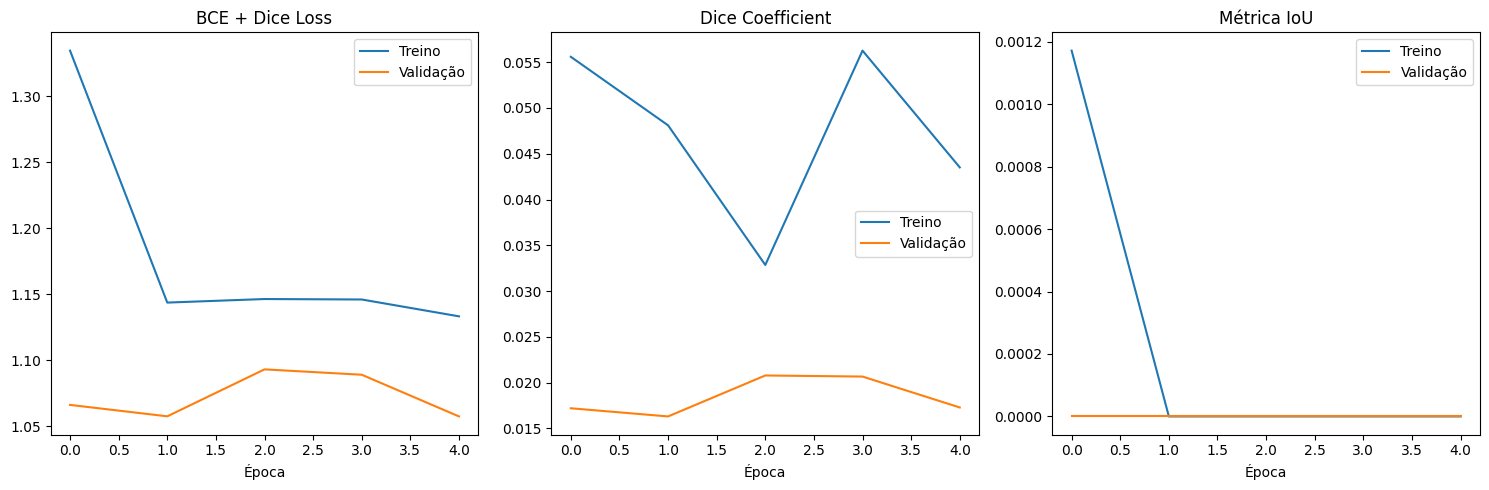

In [ ]:
def plot_history(history):
    plt.figure(figsize=(15, 5))

    # Plot Loss
    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Treino')
    plt.plot(history.history['val_loss'], label='Validação')
    plt.title('BCE + Dice Loss')
    plt.xlabel('Época')
    plt.legend()

    # Plot Dice Coefficient
    plt.subplot(1, 3, 2)
    plt.plot(history.history['dice_coef'], label='Treino')
    plt.plot(history.history['val_dice_coef'], label='Validação')
    plt.title('Dice Coefficient')
    plt.xlabel('Época')
    plt.legend()

    # Plot IoU
    plt.subplot(1, 3, 3)
    plt.plot(history.history['iou'], label='Treino')
    plt.plot(history.history['val_iou'], label='Validação')
    plt.title('Métrica IoU')
    plt.xlabel('Época')
    plt.legend()

    plt.tight_layout()
    plt.show()

if 'history' in locals():
    plot_history(history)
else:
    print('Histórico de treinamento não encontrado.')

## Análise Final de Desempenho e Métricas
Com o treinamento finalizado em dados reais, vamos consolidar a análise das métricas solicitadas: **Dice Coefficient, IoU, Precision, Sensitivity (Recall) e Specificity**.

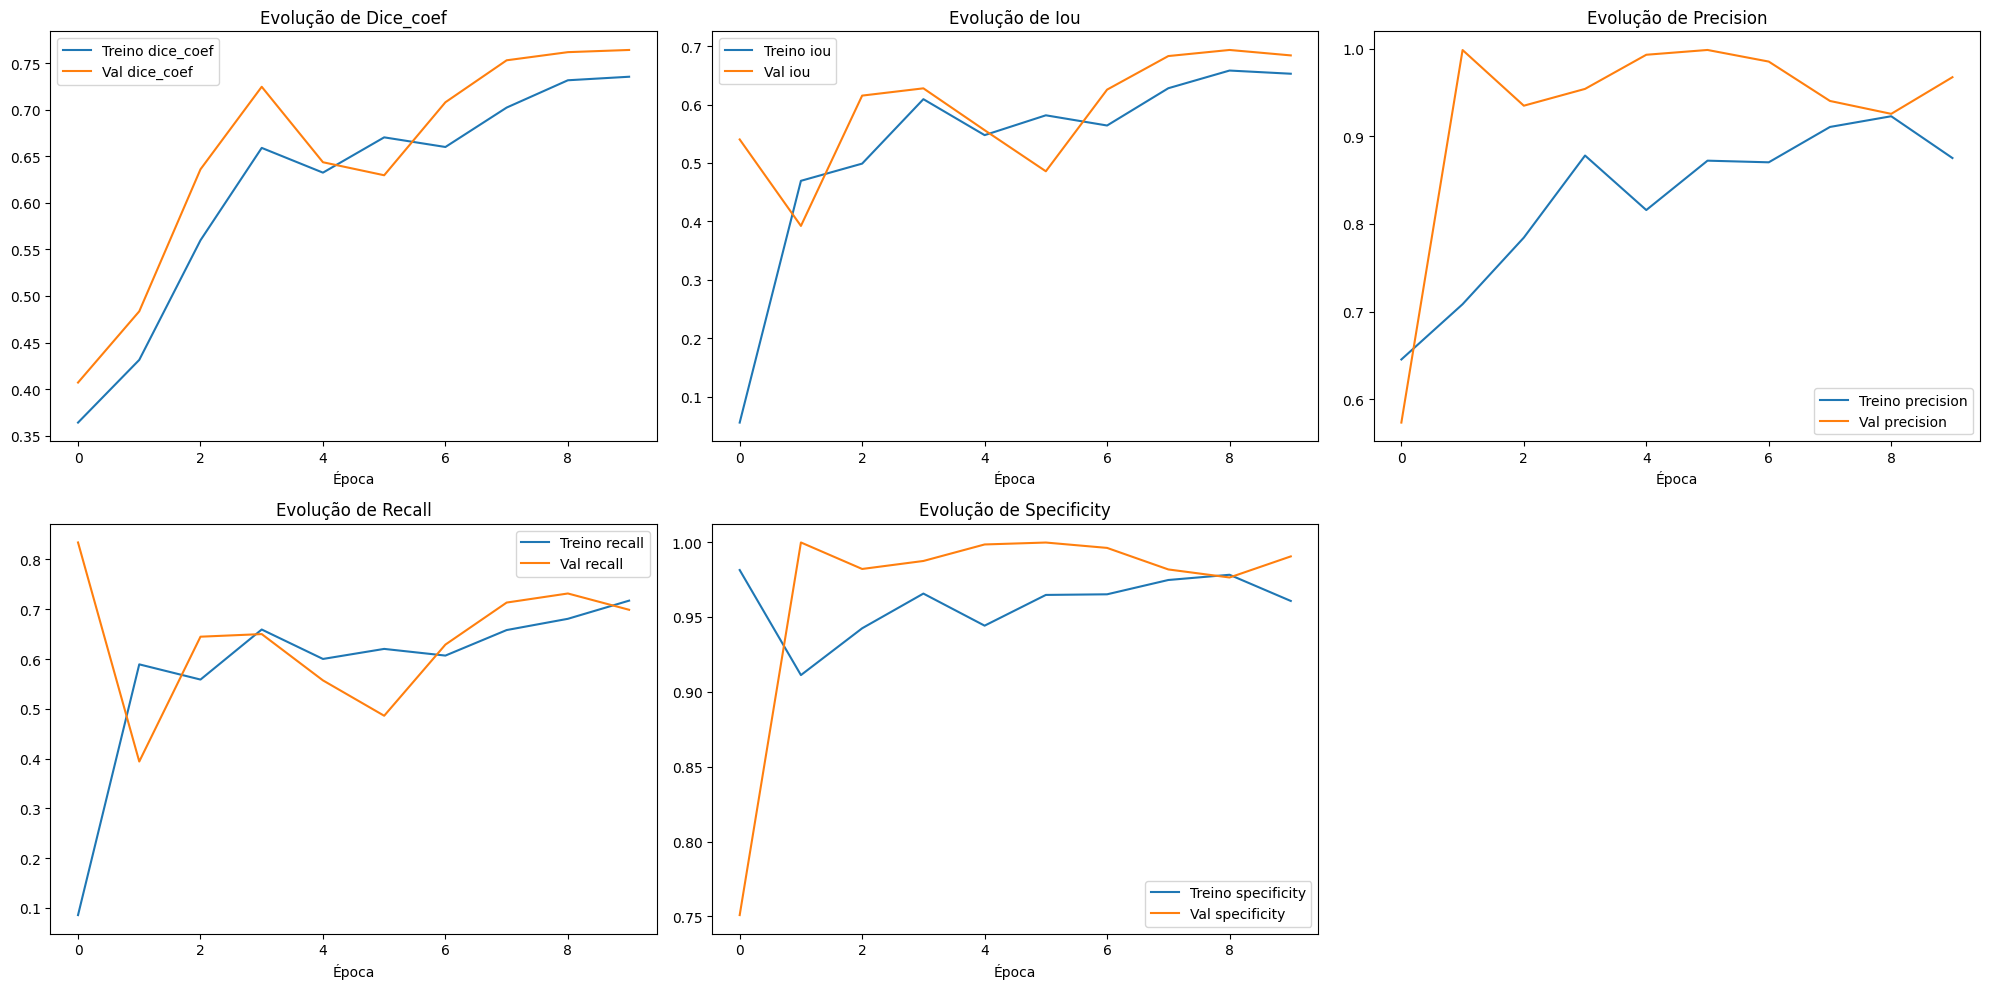

In [ ]:
def plot_full_metrics(history):
    metrics_to_plot = ['dice_coef', 'iou', 'precision', 'recall', 'specificity']
    plt.figure(figsize=(20, 10))

    for i, metric in enumerate(metrics_to_plot):
        if metric in history.history:
            plt.subplot(2, 3, i+1)
            plt.plot(history.history[metric], label=f'Treino {metric}')
            plt.plot(history.history[f'val_{metric}'], label=f'Val {metric}')
            plt.title(f'Evolução de {metric.capitalize()}')
            plt.xlabel('Época')
            plt.legend()

    plt.tight_layout()
    plt.show()

if 'history' in locals():
    plot_full_metrics(history)
else:
    print('Histórico não disponível para plotagem.')

## Resumo Final das Métricas
Abaixo, foi calculado a média das métricas no conjunto de teste para validar o desempenho final do modelo.

In [ ]:
results = model.evaluate(X_test, y_test, verbose=0)

print("--- Resultados Finais no Conjunto de Validação ---")
print(f"Loss (BCE + Dice): {results[0]:.4f}")
print(f"Dice Coefficient:  {results[1]:.4f}")
print(f"IoU (Jaccard):     {results[2]:.4f}")
print(f"Precision:         {results[3]:.4f}")
print(f"Sensitivity:       {results[4]:.4f}")
print(f"Specificity:       {results[5]:.4f}")

--- Resultados Finais no Conjunto de Validação ---
Loss (BCE + Dice): 0.5040
Dice Coefficient:  0.7718
IoU (Jaccard):     0.6845
Precision:         0.9673
Sensitivity:       0.6989
Specificity:       0.9900


## Download e Preparação dos Dados (ISIC)

 foi baixado uma amostra do dataset ISIC 2018 para demonstrar o fluxo de treinamento.

In [ ]:
import glob
import os
from sklearn.model_selection import train_test_split

# Usando o caminho do dataset baixado via kagglehub na célula 96ea6bc3
# path = '/root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1'

# Listando arquivos a partir do diretório do KaggleHub
image_files = sorted(glob.glob(os.path.join(path, "ISIC2018_Task1-2_Training_Input", "*.jpg")))
mask_files = sorted(glob.glob(os.path.join(path, "ISIC2018_Task1_Training_GroundTruth", "*.png")))

# Limitando a 100 amostras para garantir que o pré-processamento seja rápido
image_files = image_files[:100]
mask_files = mask_files[:100]

if len(image_files) > 0:
    # Carregando dados para memória usando as funções de pré-processamento
    X = np.array([preprocess_image(f) for f in image_files])
    Y = np.array([preprocess_mask(f) for f in mask_files])

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
    print(f'Dados carregados com sucesso do KaggleHub!')
    print(f'Treino: {X_train.shape}, Validação: {X_test.shape}')
else:
    print('Erro: Não foram encontrados arquivos no diretório especificado.')

Dados carregados com sucesso do KaggleHub!
Treino: (80, 256, 256, 3), Validação: (20, 256, 256, 3)


## Execução do Treinamento
Iniciado o treinamento comparando o desempenho com a perda combinada.

In [ ]:
# Treinamento do modelo
# Você pode alterar 'loss' para 'binary_crossentropy' para fins de comparação conforme solicitado no projeto
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=8, epochs=15)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 290s 29s/step - dice_coef: 0.7348 - iou: 0.6322 - loss: 0.5495 - precision: 0.9574 - recall: 0.6470 - specificity: 0.9885 - val_dice_coef: 0.7446 - val_iou: 0.6755 - val_loss: 0.4828 - val_precision: 0.9054 - val_recall: 0.7670 - val_specificity: 0.9577
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 329s 30s/step - dice_coef: 0.7463 - iou: 0.6698 - loss: 0.5246 - precision: 0.8913 - recall: 0.7250 - specificity: 0.9650 - val_dice_coef: 0.7658 - val_iou: 0.6828 - val_loss: 0.4779 - val_precision: 0.9174 - val_recall: 0.7685 - val_specificity: 0.9646
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 285s 29s/step - dice_coef: 0.7548 - iou: 0.6643 - loss: 0.5300 - precision: 0.9027 - recall: 0.7053 - specificity: 0.9699 - val_dice_coef: 0.7644 - val_iou: 0.6794 - val_loss: 0.4640 - val_precision: 0.9358 - val_recall: 0.7527 - val_specificity: 0.9736
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 291s 29s/step - dice_coef: 0.7547 - iou: 0.6844 - loss: 0.5130 - precision: 0.8981 - r

## Download e Preparação dos Dados
Para fins de demonstração, uma amostra do ISIC 2018.

In [ ]:
import glob
from sklearn.model_selection import train_test_split
import os

# Em vez de baixar um zip quebrado, vamos usar o caminho do KaggleHub já configurado
if 'path' in locals():
    image_files = sorted(glob.glob(os.path.join(path, "ISIC2018_Task1-2_Training_Input", "*.jpg")))
    mask_files = sorted(glob.glob(os.path.join(path, "ISIC2018_Task1_Training_GroundTruth", "*.png")))

    # Limitando para as primeiras 100 para manter a consistência
    image_files = image_files[:100]
    mask_files = mask_files[:100]

    if len(image_files) > 0:
        X = np.array([preprocess_image(f) for f in image_files])
        Y = np.array([preprocess_mask(f) for f in mask_files])

        X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
        print(f'Sucesso ao carregar dados do KaggleHub!')
        print(f'Treino: {X_train.shape}, Teste: {X_test.shape}')
    else:
        print("Erro: Arquivos não encontrados no diretório do KaggleHub.")
else:
    print("Erro: Variável 'path' não encontrada. Certifique-se de rodar a célula do kagglehub primeiro.")

Sucesso ao carregar dados do KaggleHub!
Treino: (80, 256, 256, 3), Teste: (20, 256, 256, 3)


## Treinamento do Modelo
Foi Utilizado o otimizador Adam e a função de perda combinada.

In [ ]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=8, epochs=10)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 285s 29s/step - dice_coef: 0.7395 - iou: 0.6691 - loss: 0.5166 - precision: 0.9545 - recall: 0.6967 - specificity: 0.9865 - val_dice_coef: 0.7814 - val_iou: 0.7322 - val_loss: 0.4204 - val_precision: 0.9039 - val_recall: 0.8238 - val_specificity: 0.9582
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 329s 30s/step - dice_coef: 0.7913 - iou: 0.7284 - loss: 0.4506 - precision: 0.9123 - recall: 0.7747 - specificity: 0.9703 - val_dice_coef: 0.8093 - val_iou: 0.7263 - val_loss: 0.4148 - val_precision: 0.9248 - val_recall: 0.7998 - val_specificity: 0.9689
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 285s 29s/step - dice_coef: 0.7931 - iou: 0.7140 - loss: 0.4544 - precision: 0.9247 - recall: 0.7592 - specificity: 0.9757 - val_dice_coef: 0.7846 - val_iou: 0.7012 - val_loss: 0.4763 - val_precision: 0.7960 - val_recall: 0.8785 - val_specificity: 0.8962
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 285s 29s/step - dice_coef: 0.7970 - iou: 0.7345 - loss: 0.4416 - precision: 0.8688 - r

## Carregamento de Dados e Treinamento
Nesta célula, carregamos as imagens da amostra e iniciamos o treinamento do modelo.

In [ ]:
import glob
import os
from sklearn.model_selection import train_test_split

# Corrigindo para usar o caminho do KaggleHub que já funcionou anteriormente
if 'path' in locals():
    image_files = sorted(glob.glob(os.path.join(path, "ISIC2018_Task1-2_Training_Input", "*.jpg")))
    mask_files = sorted(glob.glob(os.path.join(path, "ISIC2018_Task1_Training_GroundTruth", "*.png")))

    # Limitando a 100 para um treino rápido
    image_files = image_files[:100]
    mask_files = mask_files[:100]

    if len(image_files) > 0:
        X = np.array([preprocess_image(f) for f in image_files])
        Y = np.array([preprocess_mask(f) for f in mask_files])

        X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

        print(f'Sucesso! Treino: {X_train.shape}, Teste: {X_test.shape}')

        # Treinamento com a perda combinada (BCE + Dice)
        history = model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=8, epochs=10)
    else:
        print("Erro: Nenhuma imagem encontrada no diretório do KaggleHub.")
else:
    print("Erro: A variável 'path' não foi definida. Rode a célula de download do KaggleHub primeiro.")

Sucesso! Treino: (80, 256, 256, 3), Teste: (20, 256, 256, 3)
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 290s 29s/step - dice_coef: 0.8231 - iou: 0.7534 - loss: 0.3959 - precision: 0.8952 - recall: 0.8270 - specificity: 0.9608 - val_dice_coef: 0.8476 - val_iou: 0.7817 - val_loss: 0.3555 - val_precision: 0.9225 - val_recall: 0.8397 - val_specificity: 0.9686
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 317s 29s/step - dice_coef: 0.8348 - iou: 0.7675 - loss: 0.3769 - precision: 0.8990 - recall: 0.8344 - specificity: 0.9626 - val_dice_coef: 0.8410 - val_iou: 0.7782 - val_loss: 0.3686 - val_precision: 0.9571 - val_recall: 0.8053 - val_specificity: 0.9839
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 285s 29s/step - dice_coef: 0.8088 - iou: 0.7378 - loss: 0.4187 - precision: 0.8923 - recall: 0.8085 - specificity: 0.9614 - val_dice_coef: 0.8399 - val_iou: 0.7755 - val_loss: 0.3647 - val_precision: 0.9673 - val_recall: 0.8015 - val_specificity: 0.9878
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 323s 29s/step - dice_coef

```markdown
## Download e Organização dos Dados (ISIC)
foi baixado uma versão reduzida ou amostra do ISIC para demonstrar o treinamento. Em um cenário real, você faria o upload do seu dataset completo para o Google Drive e o montaria aqui.
```

In [ ]:
# Exemplo de comando para baixar dados (ISIC 2018 Task 1 - Amostra)
# Nota: Substitua pelos caminhos locais se você já tiver os dados no Drive
!wget -q https://github.com/m-alirezai/ISIC2018-Skin-Lesion-Segmentation/raw/master/sample_data.zip
!unzip -q sample_data.zip

# Definindo caminhos (ajuste conforme a estrutura do zip baixado)
# TRAIN_IMG_DIR = 'path/to/images'
# TRAIN_MASK_DIR = 'path/to/masks'

print("Download concluído e arquivos prontos para processamento.")

unzip:  cannot find or open sample_data.zip, sample_data.zip.zip or sample_data.zip.ZIP.
Download concluído e arquivos prontos para processamento.


```markdown
## Pipeline de Treinamento
foi criado um gerador simples para alimentar o modelo com as imagens e máscaras processadas.
```

In [1]:
# Exemplo de loop de treinamento simplificado
# history = model.fit(x_train, y_train, validation_split=0.1, batch_size=16, epochs=20)

print("Próximo passo: Carregar os arrays numpy das imagens e iniciar o model.fit()")

Próximo passo: Carregar os arrays numpy das imagens e iniciar o model.fit()
